## Step 0 — Install Dependencies


In [22]:
!pip install \
  "Pillow==9.5.0" \
  "scikit-image==0.21.0" \
  "scikit-learn==1.3.2" \
  --force-reinstall -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 13.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.7/22.7 MB 15.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.6/317.6 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 17.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.14.1 requires scikit-learn<2,>=1.4.2, but you have scikit-learn 1.3.2 which is incompatible.
hdbscan 0.8.41 

In [2]:
# ── Install missing packages (run once per Colab session)
import subprocess, sys

PACKAGES = [
    'optuna',
    'shap',
    'xgboost',          # usually pre-installed, but pin latest
    'scikit-learn',     # usually pre-installed
]

for pkg in PACKAGES:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', pkg],
        capture_output=True, text=True
    )
    status = 'OK' if result.returncode == 0 else 'FAILED'
    print(f'  [{status}] {pkg}')

# Verify imports immediately after install
import xgboost as xgb
import shap
import optuna
from sklearn.model_selection import train_test_split

print(f'\nVersions confirmed:')
print(f'  xgboost  : {xgb.__version__}')
print(f'  shap     : {shap.__version__}')
print(f'  optuna   : {optuna.__version__}')
print('All packages ready.')


  [OK] optuna
  [OK] shap
  [OK] xgboost
  [OK] scikit-learn

Versions confirmed:
  xgboost  : 3.2.0
  shap     : 0.51.0
  optuna   : 4.8.0
All packages ready.


# ICU Time-Series Encoder — XGBoost + SHAP
> **Input** : `icu_hourly_features_24h.parquet` · `icu_static_features.parquet` · `icu_risk_scores.parquet`  
> **Output** : encoder feature matrix · predictions · SHAP values · visualisation report  
> **Targets** : mortality risk · sepsis alert · organ dysfunction · criticality tier  
> **Leakage policy** : split by `stay_id` before any scaling; score columns are targets-only


## Step 1 — Environment & Paths

In [1]:
import warnings, logging, random, json
from pathlib import Path
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('ICU_Encoder')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    mean_absolute_error, brier_score_loss, classification_report
)

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

BASE     = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

HOURLY_PATH  = BASE / 'icu_hourly_features_24h.parquet'
STATIC_PATH  = BASE / 'icu_static_features.parquet'
SCORES_PATH  = BASE / 'icu_risk_scores.parquet'
FEAT_OUT     = BASE / 'icu_encoder_features.parquet'
PRED_OUT     = BASE / 'icu_encoder_predictions.parquet'
REPORT_PNG   = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_encoder_report.png')

# ── Plot theme
DARK_BG = '#0F172A'; CARD_BG = '#1E293B'; TEXT = '#F1F5F9'; GRID = '#334155'
PAL = {'green':'#16A34A','yellow':'#CA8A04','orange':'#EA580C',
       'red':'#DC2626','blue':'#2563EB','purple':'#7C3AED','teal':'#0891B2'}
plt.rcParams.update({
    'figure.facecolor':DARK_BG,'axes.facecolor':CARD_BG,'axes.edgecolor':GRID,
    'axes.labelcolor':TEXT,'axes.titlecolor':TEXT,'xtick.color':TEXT,
    'ytick.color':TEXT,'text.color':TEXT,'grid.color':GRID,'grid.linewidth':0.5,
    'axes.grid':True,'axes.titlesize':12,'axes.labelsize':10,
    'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,
})
log.info('Environment ready. XGBoost %s | SHAP %s', xgb.__version__, shap.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2 — Load All Parquet Files

In [2]:
hourly  = pd.read_parquet(HOURLY_PATH)
static  = pd.read_parquet(STATIC_PATH)
scores  = pd.read_parquet(SCORES_PATH)

log.info('Hourly  : %s | stays: %d', hourly.shape, hourly['stay_id'].nunique())
log.info('Static  : %s | stays: %d', static.shape, static['stay_id'].nunique())
log.info('Scores  : %s | stays: %d', scores.shape, scores['stay_id'].nunique())

# Confirm all stays align
common_stays = set(hourly['stay_id']) & set(static['stay_id']) & set(scores['stay_id'])
log.info('Stays present in all 3 files: %d', len(common_stays))
assert len(common_stays) > 50_000, 'Unexpected stay count mismatch — check parquet files'


## Step 3 — Time-Series Feature Aggregation
> Each stay's 24-hour window → 5 statistics per variable (mean, std, min, max, last).  
> Variable names follow `{variable}_{stat}` convention for SHAP readability.  
> Missing-flag columns aggregated as `{variable}_missing_rate` (mean of the binary flag).


In [5]:
# ── Columns that exist in hourly data
CLINICAL_VARS = [
    'HR','RR','SBP','DBP','MAP','TEMP','SpO2','GCS',
    'Sodium','Potassium','Creatinine','WBC','Hematocrit',
    'Platelets','Bilirubin','pH','PaO2','FiO2','PF_ratio','SF_ratio',
]
# Only keep vars that are actually in the data
CLINICAL_VARS = [v for v in CLINICAL_VARS if v in hourly.columns]

MISSING_VARS = [c for c in hourly.columns if c.endswith('_missing')]

# ── Relative hour (0-23) — never use absolute timestamp
hourly = hourly.sort_values(['stay_id','hour_ts'])
hourly['rel_hour'] = hourly.groupby('stay_id').cumcount()

# ── Aggregate clinical variables: mean / std / min / max / last
log.info('Aggregating time-series features...')

agg_funcs = {'mean': np.nanmean, 'std': np.nanstd,
             'min': np.nanmin,  'max': np.nanmax}

# Build agg dict for pandas .agg()
agg_dict = {}
for var in CLINICAL_VARS:
    agg_dict[f'{var}_mean'] = pd.NamedAgg(column=var, aggfunc='mean')
    agg_dict[f'{var}_std']  = pd.NamedAgg(column=var, aggfunc='std')
    agg_dict[f'{var}_min']  = pd.NamedAgg(column=var, aggfunc='min')
    agg_dict[f'{var}_max']  = pd.NamedAgg(column=var, aggfunc='max')
    # 'last' = value in the final observed hour
    agg_dict[f'{var}_last'] = pd.NamedAgg(column=var, aggfunc='last')

# Missing rate per variable
for mv in MISSING_VARS:
    base = mv.replace('_missing', '')
    agg_dict[f'{base}_missing_rate'] = pd.NamedAgg(column=mv, aggfunc='mean')

# Ventilation: any hour on vent
if 'vent' in hourly.columns:
    agg_dict['vent_any'] = pd.NamedAgg(column='vent', aggfunc='max')
    agg_dict['vent_hours'] = pd.NamedAgg(column='vent', aggfunc='sum')

ts_features = (
    hourly
    .groupby('stay_id', sort=False)
    .agg(**agg_dict)
    .reset_index()
)

log.info('Time-series feature matrix: %s', ts_features.shape)
log.info('Feature columns: %s', list(ts_features.columns[:10]), '...')


## Step 4 — Static Feature Preparation
> Gender encoded as binary (M=1, F=0). No label leakage from scores table.


In [6]:
STATIC_FEAT_COLS = ['stay_id','age_icu','gender','is_elective','has_chronic','urine_24h']
static_feats = static[STATIC_FEAT_COLS].copy()

# Encode gender: M=1, F=0 — explicit, never rely on auto-encoding
static_feats['gender_male'] = (static_feats['gender'] == 'M').astype('int8')
static_feats.drop(columns=['gender'], inplace=True)

# Rename for explainability clarity
static_feats = static_feats.rename(columns={
    'age_icu':     'static_age',
    'is_elective': 'static_is_elective',
    'has_chronic': 'static_has_chronic',
    'urine_24h':   'static_urine_24h',
    'gender_male': 'static_gender_male',
})

log.info('Static features: %s', list(static_feats.columns))


## Step 5 — Extract Targets
> **Rule**: score columns are ONLY in the target table. They are NEVER copied into the feature matrix.


In [7]:
# ── Columns that are pure targets — must NEVER appear as features
TARGET_COLS = [
    'qsofa_score','qsofa_risk','sepsis_screen_positive',
    'sofa_score','sofa_resp','sofa_coag','sofa_liver','sofa_cardio','sofa_cns','sofa_renal',
    'sofa_risk','organ_dysfunction',
    'apache2_score','apache2_pred_mortality','apache2_risk','apache2_aps','apache2_age','apache2_chronic',
    'saps3_score','saps3_pred_mortality','saps3_risk',
    'composite_mortality_risk','sepsis_alert','organ_failure_count',
    'criticality_tier','priority_rank',
    'alert_respiratory_failure','alert_renal_failure','alert_coagulopathy',
    'alert_liver_failure','alert_neurological','alert_hemodynamic',
]

TARGETS_KEEP = [
    'stay_id',
    'apache2_pred_mortality',   # continuous mortality risk [0,1]
    'sepsis_alert',             # binary
    'organ_dysfunction',        # binary
    'criticality_tier',         # 5-class string
]

targets = scores[TARGETS_KEEP].copy()

# Encode criticality tier as ordinal integer (preserves clinical order)
TIER_ORDER = {'LOW':0,'MODERATE':1,'HIGH':2,'SEVERE':3,'CRITICAL':4}
targets['criticality_tier_int'] = targets['criticality_tier'].map(TIER_ORDER)

log.info('Target distribution — criticality tier:')
print(targets['criticality_tier'].value_counts())
log.info('Sepsis alert positive: %.1f%%', targets['sepsis_alert'].mean()*100)
log.info('Organ dysfunction: %.1f%%', targets['organ_dysfunction'].mean()*100)


criticality_tier
SEVERE      69867
HIGH        17868
CRITICAL     4084
MODERATE     2267
LOW           276
Name: count, dtype: int64


## Step 6 — Build Master Feature Matrix
> Merge TS aggregates + static. Verify zero overlap with target columns.


In [8]:
features = ts_features.merge(static_feats, on='stay_id', how='inner')

# ── Anti-leakage assertion: no target column must appear in features
leaked = set(features.columns) & set(TARGET_COLS)
assert len(leaked) == 0, f'DATA LEAKAGE DETECTED — columns in both features and targets: {leaked}'
log.info('Anti-leakage check PASSED — 0 target columns in feature matrix.')

# ── Drop any identifier columns that might have crept in
for drop_col in ['subject_id','hadm_id','intime','outtime','hour_ts']:
    if drop_col in features.columns:
        features.drop(columns=[drop_col], inplace=True)

# ── Merge with targets (join on stay_id)
master = features.merge(targets, on='stay_id', how='inner')
assert master['stay_id'].nunique() == len(master), 'Duplicate stay_ids after merge'

FEATURE_COLS = [c for c in features.columns if c != 'stay_id']
log.info('Feature matrix: %d stays x %d features', len(master), len(FEATURE_COLS))
log.info('First 10 feature names: %s', FEATURE_COLS[:10])

# ── Save full feature names for SHAP explainability
feature_meta = {
    'feature_names': FEATURE_COLS,
    'n_features': len(FEATURE_COLS),
    'clinical_vars': CLINICAL_VARS,
    'static_vars': [c for c in FEATURE_COLS if c.startswith('static_')],
}
with open(MODEL_DIR / 'feature_meta.json','w') as f:
    json.dump(feature_meta, f, indent=2)
log.info('Feature metadata saved.')


## Step 7 — Train / Val / Test Split
> Split by `stay_id` (70/15/15). Stratified on criticality tier.  
> **No patient-level leakage**: if a patient has 2 stays, both go to the same fold.  
> Scalers and imputers fitted ONLY on train, then applied to val and test.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── Group by subject_id to prevent patient-level leakage
# (a patient's 2nd stay must not be in val if 1st stay is in train)
subject_map = scores[['stay_id','subject_id']].set_index('stay_id')['subject_id']
master['subject_id'] = master['stay_id'].map(subject_map)

# Split unique subjects (not stays)
unique_subjects = master['subject_id'].unique()
subj_train, subj_temp = train_test_split(
    unique_subjects, test_size=0.30, random_state=SEED
)
subj_val, subj_test = train_test_split(
    subj_temp, test_size=0.50, random_state=SEED
)

train_mask = master['subject_id'].isin(subj_train)
val_mask   = master['subject_id'].isin(subj_val)
test_mask  = master['subject_id'].isin(subj_test)

assert (train_mask.sum() + val_mask.sum() + test_mask.sum()) == len(master)
# Critical: no subject appears in 2 splits
assert len(set(subj_train) & set(subj_val)) == 0
assert len(set(subj_train) & set(subj_test)) == 0
assert len(set(subj_val)   & set(subj_test)) == 0
log.info('Subject-level leakage check PASSED.')

master['split'] = 'train'
master.loc[val_mask,  'split'] = 'val'
master.loc[test_mask, 'split'] = 'test'

log.info('Train: %d stays | Val: %d stays | Test: %d stays',
         train_mask.sum(), val_mask.sum(), test_mask.sum())

X_train = master.loc[train_mask, FEATURE_COLS].copy()
X_val   = master.loc[val_mask,   FEATURE_COLS].copy()
X_test  = master.loc[test_mask,  FEATURE_COLS].copy()

# ── Impute then scale — fitted on TRAIN ONLY
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

# XGBoost handles scale internally, but StandardScaler helps Optuna converge
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)
X_test_sc  = scaler.transform(X_test_imp)

# Wrap back into DataFrames with named columns for SHAP
X_train_df = pd.DataFrame(X_train_sc, columns=FEATURE_COLS, index=X_train.index)
X_val_df   = pd.DataFrame(X_val_sc,   columns=FEATURE_COLS, index=X_val.index)
X_test_df  = pd.DataFrame(X_test_sc,  columns=FEATURE_COLS, index=X_test.index)

# Targets per split
def get_targets(mask):
    return {
        'mortality':    master.loc[mask, 'apache2_pred_mortality'].values,
        'sepsis':       master.loc[mask, 'sepsis_alert'].values.astype(int),
        'organ':        master.loc[mask, 'organ_dysfunction'].values.astype(int),
        'criticality':  master.loc[mask, 'criticality_tier_int'].values.astype(int),
    }

y_train = get_targets(train_mask)
y_val   = get_targets(val_mask)
y_test  = get_targets(test_mask)

# Save imputer/scaler stats for inference
import pickle
with open(MODEL_DIR / 'imputer.pkl', 'wb') as f: pickle.dump(imputer, f)
with open(MODEL_DIR / 'scaler.pkl',  'wb') as f: pickle.dump(scaler, f)
log.info('Imputer and scaler saved.')


## Step 8 — Optuna Hyperparameter Search
> 50 trials per model. Early stopping on val AUC. No test set touched.


In [10]:
def make_xgb_objective(X_tr, y_tr, X_vl, y_vl, task='binary'):
    """Returns an Optuna objective function for a given task."""
    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 200, 1200),
            'max_depth':         trial.suggest_int('max_depth', 3, 9),
            'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
            'random_state':      SEED,
            'n_jobs':            -1,
            'tree_method':       'hist',
            'device':            'cuda' if xgb.build_info().get('USE_CUDA') else 'cpu',
        }
        if task == 'binary':
            params.update({'objective':'binary:logistic','eval_metric':'auc'})
            model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
            model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
            preds = model.predict_proba(X_vl)[:,1]
            return roc_auc_score(y_vl, preds)
        elif task == 'multiclass':
            n_cls = len(np.unique(y_tr))
            params.update({'objective':'multi:softprob','num_class':n_cls,'eval_metric':'mlogloss'})
            model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
            model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
            preds = model.predict_proba(X_vl)
            return roc_auc_score(y_vl, preds, multi_class='ovr', average='macro')
        else:  # regression
            params.update({'objective':'reg:squarederror','eval_metric':'mae'})
            model = xgb.XGBRegressor(**params, early_stopping_rounds=30)
            model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
            preds = model.predict(X_vl).clip(0,1)
            return -mean_absolute_error(y_vl, preds)  # maximise
    return objective

N_TRIALS = 50

TASK_CONFIG = {
    'mortality':   ('regression',  y_train['mortality'],  y_val['mortality']),
    'sepsis':      ('binary',      y_train['sepsis'],     y_val['sepsis']),
    'organ':       ('binary',      y_train['organ'],      y_val['organ']),
    'criticality': ('multiclass',  y_train['criticality'],y_val['criticality']),
}

best_params = {}
for task_name, (task_type, y_tr, y_vl) in TASK_CONFIG.items():
    log.info('=== Optuna search: %s (%s) ===', task_name, task_type)
    direction = 'maximize'
    study = optuna.create_study(direction=direction, sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(
        make_xgb_objective(X_train_df.values, y_tr, X_val_df.values, y_vl, task_type),
        n_trials=N_TRIALS, show_progress_bar=True
    )
    best_params[task_name] = study.best_params
    log.info('Best val score for %s: %.4f', task_name, study.best_value)

with open(MODEL_DIR / 'best_hyperparams.json','w') as f:
    json.dump(best_params, f, indent=2)
log.info('Best hyperparameters saved.')


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

## Step 9 — Train Final Models on Train+Val
> After Optuna, retrain on train+val combined with best params.  
> Test set used ONLY for final evaluation — never seen during tuning.


In [11]:
import pickle

X_trainval = pd.concat([X_train_df, X_val_df], axis=0).reset_index(drop=True)

def get_trainval_targets(key):
    return np.concatenate([y_train[key], y_val[key]])

trained_models = {}

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    p = best_params[task_name].copy()
    p.update({'random_state': SEED, 'n_jobs': -1, 'tree_method': 'hist'})
    y_tv = get_trainval_targets(task_name)

    if task_type == 'binary':
        p.update({'objective':'binary:logistic'})
        model = xgb.XGBClassifier(**p)
    elif task_type == 'multiclass':
        n_cls = len(np.unique(y_tv))
        p.update({'objective':'multi:softprob','num_class':n_cls})
        model = xgb.XGBClassifier(**p)
    else:
        p.update({'objective':'reg:squarederror'})
        model = xgb.XGBRegressor(**p)

    model.fit(X_trainval.values, y_tv, verbose=False)
    trained_models[task_name] = model

    # Save model in binary format
    model_path = MODEL_DIR / f'xgb_{task_name}.ubj'
    model.save_model(str(model_path))
    log.info('Saved: %s', model_path)

log.info('All models trained and saved.')


## Step 10 — Test Set Evaluation
> First and only time test set is used. Metrics: AUROC, AUPRC, Brier score, F1.


In [12]:
eval_results = {}

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    model = trained_models[task_name]
    y_true = y_test[task_name]

    if task_type == 'regression':
        y_pred = model.predict(X_test_df.values).clip(0, 1)
        mae  = mean_absolute_error(y_true, y_pred)
        brier = brier_score_loss(np.round(y_true).astype(int), y_pred)
        eval_results[task_name] = {'MAE': round(mae,4), 'Brier': round(brier,4)}
        log.info('%s — MAE: %.4f | Brier: %.4f', task_name, mae, brier)

    elif task_type == 'binary':
        y_prob = model.predict_proba(X_test_df.values)[:,1]
        y_pred_cls = (y_prob >= 0.5).astype(int)
        auroc = roc_auc_score(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)
        f1    = f1_score(y_true, y_pred_cls)
        brier = brier_score_loss(y_true, y_prob)
        eval_results[task_name] = {
            'AUROC':round(auroc,4),'AUPRC':round(auprc,4),
            'F1':round(f1,4),'Brier':round(brier,4)
        }
        log.info('%s — AUROC: %.4f | AUPRC: %.4f | F1: %.4f | Brier: %.4f',
                 task_name, auroc, auprc, f1, brier)

    elif task_type == 'multiclass':
        y_prob = model.predict_proba(X_test_df.values)
        y_pred_cls = np.argmax(y_prob, axis=1)
        auroc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        f1    = f1_score(y_true, y_pred_cls, average='macro')
        eval_results[task_name] = {'AUROC_macro':round(auroc,4),'F1_macro':round(f1,4)}
        log.info('%s — AUROC macro: %.4f | F1 macro: %.4f', task_name, auroc, f1)
        print(classification_report(y_true, y_pred_cls,
              target_names=['LOW','MODERATE','HIGH','SEVERE','CRITICAL']))

with open(MODEL_DIR / 'eval_results.json','w') as f:
    json.dump(eval_results, f, indent=2)
print('\nEvaluation Summary:')
print(json.dumps(eval_results, indent=2))


              precision    recall  f1-score   support

         LOW       0.93      0.88      0.90        42
    MODERATE       0.98      0.96      0.97       361
        HIGH       0.99      0.99      0.99      2688
      SEVERE       1.00      1.00      1.00     10559
    CRITICAL       0.98      0.97      0.98       585

    accuracy                           0.99     14235
   macro avg       0.97      0.96      0.97     14235
weighted avg       0.99      0.99      0.99     14235


Evaluation Summary:
{
  "mortality": {
    "MAE": 0.0051,
    "Brier": 0.0945
  },
  "sepsis": {
    "AUROC": 1.0,
    "AUPRC": 1.0,
    "F1": 0.9999,
    "Brier": 0.0002
  },
  "organ": {
    "AUROC": 0.9999,
    "AUPRC": 1.0,
    "F1": 0.9998,
    "Brier": 0.0004
  },
  "criticality": {
    "AUROC_macro": 0.9999,
    "F1_macro": 0.9679
  }
}


## Step 11 — SHAP Explainability
> TreeExplainer (exact, not approximate) on all 4 models.  
> Output: `shap_{feature}` columns per model — named for readability.  
> Positive SHAP = pushes risk up. Negative = pushes risk down.


In [13]:
log.info('Computing SHAP values on test set...')
shap_outputs = {}

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    model = trained_models[task_name]
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_test_df)

    if task_type == 'multiclass':
        # For multiclass, use the CRITICAL class (index 4) — most clinically relevant
        sv_use = sv[4] if isinstance(sv, list) else sv[:, :, 4]
    elif isinstance(sv, list):
        sv_use = sv[1]  # positive class for binary
    else:
        sv_use = sv

    # Name each SHAP column: shap_{task}_{feature}
    shap_col_names = [f'shap_{task_name}_{feat}' for feat in FEATURE_COLS]
    shap_df = pd.DataFrame(sv_use, columns=shap_col_names, index=X_test_df.index)
    shap_outputs[task_name] = shap_df
    log.info('SHAP computed for %s: %s', task_name, shap_df.shape)

log.info('All SHAP values computed.')


## Step 12 — Assemble & Save Prediction Output
> One row per stay in test set. Contains: stay_id · predictions · SHAP values · split label.


In [14]:
# ── Predictions on FULL dataset (train+val+test) for downstream use
X_full_imp = imputer.transform(master[FEATURE_COLS].values)
X_full_sc  = scaler.transform(X_full_imp)
X_full_df  = pd.DataFrame(X_full_sc, columns=FEATURE_COLS, index=master.index)

pred_rows = master[['stay_id','split']].copy()

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    model = trained_models[task_name]
    if task_type == 'regression':
        pred_rows[f'pred_{task_name}'] = model.predict(X_full_df.values).clip(0,1)
    elif task_type == 'binary':
        pred_rows[f'pred_{task_name}_prob'] = model.predict_proba(X_full_df.values)[:,1]
        pred_rows[f'pred_{task_name}_flag'] = (pred_rows[f'pred_{task_name}_prob'] >= 0.5).astype(int)
    elif task_type == 'multiclass':
        probs = model.predict_proba(X_full_df.values)
        pred_rows[f'pred_{task_name}_class'] = np.argmax(probs, axis=1)
        for i, tier in enumerate(['LOW','MODERATE','HIGH','SEVERE','CRITICAL']):
            pred_rows[f'pred_{task_name}_prob_{tier}'] = probs[:,i]

# Attach test-set SHAP values only
test_stay_ids = master.loc[test_mask, 'stay_id'].values
shap_all = pd.concat(list(shap_outputs.values()), axis=1)
shap_all.insert(0, 'stay_id', master.loc[test_mask, 'stay_id'].values)

# Save predictions (all splits)
pred_rows.to_parquet(PRED_OUT, index=False, engine='pyarrow', compression='snappy')
log.info('Predictions saved: %s | shape: %s', PRED_OUT, pred_rows.shape)

# Save feature matrix with split labels
feat_out_df = master[['stay_id','split'] + FEATURE_COLS].copy()
feat_out_df.to_parquet(FEAT_OUT, index=False, engine='pyarrow', compression='snappy')
log.info('Feature matrix saved: %s | shape: %s', FEAT_OUT, feat_out_df.shape)

# Save SHAP values separately (test set only — large file)
shap_path = BASE / 'icu_encoder_shap_test.parquet'
shap_all.to_parquet(shap_path, index=False, engine='pyarrow', compression='snappy')
log.info('SHAP values saved: %s | shape: %s', shap_path, shap_all.shape)


for dashboard - loading the saved models and parquet

In [48]:
from google.colab import drive
from pathlib import Path # Import Path
drive.mount('/content/drive')

BASE = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/')  # update folder name, make it a Path object
MODEL_DIR = BASE / 'Models' # Use Path object for concatenation
PARQUET_DIR = BASE / 'Parquet' # Use Path object for concatenation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import xgboost as xgb

trained_models = {}
for task in ['sepsis', 'organ', 'mortality', 'criticality']:
    model = xgb.Booster()
    model.load_model(f'{MODEL_DIR}/xgb_{task}.ubj')
    trained_models[task] = model
    print(f"✅ Loaded xgb_{task}")

✅ Loaded xgb_sepsis
✅ Loaded xgb_organ
✅ Loaded xgb_mortality
✅ Loaded xgb_criticality


In [8]:
import pandas as pd

predictions_df = pd.read_parquet(f'{PARQUET_DIR}/icu_encoder_predictions.parquet')
features_df    = pd.read_parquet(f'{PARQUET_DIR}/icu_encoder_features.parquet')
shap_df        = pd.read_parquet(f'{PARQUET_DIR}/icu_encoder_shap_test.parquet')
risk_df        = pd.read_parquet(f'{PARQUET_DIR}/icu_risk_scores.parquet')

print("✅ All parquet files loaded")
print("Predictions shape:", predictions_df.shape)

✅ All parquet files loaded
Predictions shape: (94362, 13)


In [10]:
print("Predictions columns:", predictions_df.columns.tolist())
print("Shape:", predictions_df.shape)
print(predictions_df.head(2))

Predictions columns: ['stay_id', 'split', 'pred_mortality', 'pred_sepsis_prob', 'pred_sepsis_flag', 'pred_organ_prob', 'pred_organ_flag', 'pred_criticality_class', 'pred_criticality_prob_LOW', 'pred_criticality_prob_MODERATE', 'pred_criticality_prob_HIGH', 'pred_criticality_prob_SEVERE', 'pred_criticality_prob_CRITICAL']
Shape: (94362, 13)
    stay_id  split  pred_mortality  pred_sepsis_prob  pred_sepsis_flag  \
0  30000153  train        0.236673          0.999961                 1   
1  30000213  train        0.657804          0.999907                 1   

   pred_organ_prob  pred_organ_flag  pred_criticality_class  \
0         0.999999                1                       2   
1         0.999999                1                       3   

   pred_criticality_prob_LOW  pred_criticality_prob_MODERATE  \
0                   0.000007                        0.000281   
1                   0.000002                        0.000006   

   pred_criticality_prob_HIGH  pred_criticality_prob

In [11]:
risk_df = pd.read_parquet(f'{PARQUET_DIR}/icu_risk_scores.parquet')
print(risk_df.columns.tolist())
print(risk_df.head(2))

['stay_id', 'subject_id', 'hadm_id', 'age_icu', 'gender', 'is_elective', 'has_chronic', 'qsofa_score', 'qsofa_risk', 'sepsis_screen_positive', 'sofa_score', 'sofa_resp', 'sofa_coag', 'sofa_liver', 'sofa_cardio', 'sofa_cns', 'sofa_renal', 'sofa_risk', 'organ_dysfunction', 'apache2_score', 'apache2_pred_mortality', 'apache2_risk', 'saps3_score', 'saps3_pred_mortality', 'saps3_risk', 'composite_mortality_risk', 'sepsis_alert', 'organ_failure_count', 'criticality_tier', 'priority_rank', 'alert_respiratory_failure', 'alert_renal_failure', 'alert_coagulopathy', 'alert_liver_failure', 'alert_neurological', 'alert_hemodynamic']
    stay_id  subject_id   hadm_id  age_icu gender  is_elective  has_chronic  \
0  30000153    12466550  23998182       61      M            0            0   
1  30000213    13180007  27543152       66      M            0            1   

   qsofa_score qsofa_risk  sepsis_screen_positive  ...  sepsis_alert  \
0            2       High                       1  ...        

In [12]:
static_df = pd.read_parquet(f'{PARQUET_DIR}/icu_static_features.parquet')
print(static_df.columns.tolist())
print(static_df.head(2))

['stay_id', 'subject_id', 'hadm_id', 'intime', 'outtime', 'age_icu', 'gender', 'is_elective', 'has_chronic', 'urine_24h']
    stay_id  subject_id   hadm_id              intime             outtime  \
0  39553978    10000032  29079034 2180-07-23 14:00:00 2180-07-23 23:50:47   
1  37081114    10000690  25860671 2150-11-02 19:37:00 2150-11-06 17:03:17   

   age_icu gender  is_elective  has_chronic  urine_24h  
0       52      F            0            0      175.0  
1       86      F            0            0      695.0  


In [14]:
# Step 1 — Extract true labels from risk_df
labels_df = risk_df[['stay_id', 'sepsis_screen_positive', 'organ_dysfunction',
                       'composite_mortality_risk', 'criticality_tier']].copy()

# Rename to match dashboard expectations
labels_df = labels_df.rename(columns={
    'sepsis_screen_positive'  : 'sepsis',
    'organ_dysfunction'       : 'organ',
    'composite_mortality_risk': 'mortality',
    'criticality_tier'        : 'criticality'
})

print("Label value counts:")
print(labels_df['criticality'].value_counts())
print(labels_df['sepsis'].value_counts())

Label value counts:
criticality
SEVERE      69867
HIGH        17868
CRITICAL     4084
MODERATE     2267
LOW           276
Name: count, dtype: int64
sepsis
1    88117
0     6245
Name: count, dtype: int64


In [15]:
# Step 2 — Merge with predictions (test split only)
test_preds = predictions_df[predictions_df['split'] == 'test'].reset_index(drop=True)

merged_df = test_preds.merge(labels_df, on='stay_id', how='inner')
print("Merged test shape:", merged_df.shape)

Merged test shape: (14235, 17)


In [16]:
# Step 3 — Build y_test and X_test_df
y_test = merged_df[['sepsis', 'organ', 'mortality', 'criticality']].copy()

# Encode criticality to numeric
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_test['criticality'] = le.fit_transform(y_test['criticality'])
print("Criticality classes:", le.classes_)

# Filter features to test stay_ids only
X_test_df = features_df[features_df['stay_id'].isin(merged_df['stay_id'])].reset_index(drop=True)

print("y_test shape:", y_test.shape)
print("X_test shape:", X_test_df.shape)

Criticality classes: ['CRITICAL' 'HIGH' 'LOW' 'MODERATE' 'SEVERE']
y_test shape: (14235, 4)
X_test shape: (14235, 127)


In [17]:
# Step 4 — Also store test predictions separately for dashboard plots
y_pred = {
    'sepsis'      : merged_df['pred_sepsis_prob'].values,
    'organ'       : merged_df['pred_organ_prob'].values,
    'mortality'   : merged_df['pred_mortality'].values,
    'criticality' : merged_df['pred_criticality_class'].values
}

print("✅ All ready for dashboard!")

✅ All ready for dashboard!


In [18]:
print(risk_df['composite_mortality_risk'].value_counts())

composite_mortality_risk
0.1565    2048
0.1464    1644
0.1182    1583
0.1286    1325
0.1778    1246
          ... 
0.2804       1
0.3955       1
0.4050       1
0.8372       1
0.1975       1
Name: count, Length: 3399, dtype: int64


In [19]:
labels_df['mortality'] = (labels_df['mortality'] == 'High').astype(int)

In [21]:
import xgboost as xgb
import numpy as np

class BoosterWrapper:
    """Wraps xgb.Booster to support predict_proba and predict like sklearn"""
    def __init__(self, booster):
        self.booster = booster

    def predict_proba(self, X):
        dmat = xgb.DMatrix(X)
        probs = self.booster.predict(dmat)
        return np.column_stack([1 - probs, probs])  # shape (n, 2)

    def predict(self, X):
        dmat = xgb.DMatrix(X)
        return self.booster.predict(dmat)

# Wrap all models
trained_models = {name: BoosterWrapper(model) for name, model in trained_models.items()}
print("✅ Models wrapped successfully")

✅ Models wrapped successfully


In [23]:
# Load SHAP
shap_df = pd.read_parquet(f'{PARQUET_DIR}/icu_encoder_shap_test.parquet')
print("SHAP columns:", shap_df.columns.tolist()[:10])

# master and test_mask — check if they exist
try:
    print(master.shape)
    print(test_mask.sum())
except NameError:
    print("⚠️ master / test_mask not defined — need to reconstruct")

SHAP columns: ['stay_id', 'shap_mortality_HR_mean', 'shap_mortality_HR_std', 'shap_mortality_HR_min', 'shap_mortality_HR_max', 'shap_mortality_HR_last', 'shap_mortality_RR_mean', 'shap_mortality_RR_std', 'shap_mortality_RR_min', 'shap_mortality_RR_max']
⚠️ master / test_mask not defined — need to reconstruct


In [25]:
import numpy as np
import pandas as pd
import xgboost as xgb

# ── 1. Clean X_test_df (drop non-feature columns)
drop_cols = ['stay_id', 'split', 'subject_id', 'hadm_id']
feature_cols = [c for c in features_df.columns if c not in drop_cols]

# Filter test stays only
test_stay_ids = predictions_df[predictions_df['split'] == 'test']['stay_id'].values
X_test_df = features_df[features_df['stay_id'].isin(test_stay_ids)].copy()
X_test_df = X_test_df[feature_cols].reset_index(drop=True)

# Ensure all numeric
X_test_df = X_test_df.apply(pd.to_numeric, errors='coerce').fillna(0)
FEATURE_COLS = feature_cols
print("✅ X_test_df shape:", X_test_df.shape)
print("✅ Any non-numeric:", X_test_df.select_dtypes(exclude='number').columns.tolist())

✅ X_test_df shape: (14235, 125)
✅ Any non-numeric: []


## Step 13 — Clinical Encoder Report Dashboard

In [27]:
# Check what SHAP columns exist per task
shap_df = pd.read_parquet(f'{PARQUET_DIR}/icu_encoder_shap_test.parquet')
shap_cols = [c for c in shap_df.columns if c != 'stay_id']

for task in ['mortality', 'sepsis', 'organ', 'criticality']:
    task_cols = [c for c in shap_cols if f'shap_{task}_' in c]
    print(f"{task}: {len(task_cols)} columns → {task_cols[:3]}")

mortality: 125 columns → ['shap_mortality_HR_mean', 'shap_mortality_HR_std', 'shap_mortality_HR_min']
sepsis: 125 columns → ['shap_sepsis_HR_mean', 'shap_sepsis_HR_std', 'shap_sepsis_HR_min']
organ: 125 columns → ['shap_organ_HR_mean', 'shap_organ_HR_std', 'shap_organ_HR_min']
criticality: 125 columns → ['shap_criticality_HR_mean', 'shap_criticality_HR_std', 'shap_criticality_HR_min']


In [28]:
shap_outputs = {}

for task in ['mortality', 'sepsis', 'organ', 'criticality']:
    task_cols = [c for c in shap_df.columns if f'shap_{task}_' in c]

    if task_cols:
        # Align to test stays
        shap_test = shap_df[shap_df['stay_id'].isin(test_stay_ids)][task_cols].reset_index(drop=True)

        # Store as simple namespace with .values
        class ShapObj:
            def __init__(self, arr):
                self.values = arr

        shap_outputs[task] = ShapObj(shap_test.values)
        print(f"✅ shap_outputs['{task}'] → shape: {shap_test.shape}")
    else:
        print(f"⚠️  No SHAP columns found for: {task}")

print("\nAvailable tasks in shap_outputs:", list(shap_outputs.keys()))

✅ shap_outputs['mortality'] → shape: (14235, 125)
✅ shap_outputs['sepsis'] → shape: (14235, 125)
✅ shap_outputs['organ'] → shape: (14235, 125)
✅ shap_outputs['criticality'] → shape: (14235, 125)

Available tasks in shap_outputs: ['mortality', 'sepsis', 'organ', 'criticality']


In [29]:
# FEATURE_COLS must match SHAP column count for sepsis
sepsis_shap_cols = [c for c in shap_df.columns if 'shap_sepsis_' in c]
FEATURE_COLS = [c.replace('shap_sepsis_', '') for c in sepsis_shap_cols]
print(f"✅ FEATURE_COLS count: {len(FEATURE_COLS)}")
print("Sample:", FEATURE_COLS[:5])

✅ FEATURE_COLS count: 125
Sample: ['HR_mean', 'HR_std', 'HR_min', 'HR_max', 'HR_last']


In [32]:
# Check what's actually in features_df
print("features_df columns:", features_df.columns.tolist()[:10])
print("predictions_df columns:", predictions_df.columns.tolist())

features_df columns: ['stay_id', 'split', 'HR_mean', 'HR_std', 'HR_min', 'HR_max', 'HR_last', 'RR_mean', 'RR_std', 'RR_min']
predictions_df columns: ['stay_id', 'split', 'pred_mortality', 'pred_sepsis_prob', 'pred_sepsis_flag', 'pred_organ_prob', 'pred_organ_flag', 'pred_criticality_class', 'pred_criticality_prob_LOW', 'pred_criticality_prob_MODERATE', 'pred_criticality_prob_HIGH', 'pred_criticality_prob_SEVERE', 'pred_criticality_prob_CRITICAL']


In [34]:
print("predictions_df columns:", predictions_df.columns.tolist())
print("predictions_df shape:", predictions_df.shape)
print(predictions_df.head(2))

predictions_df columns: ['stay_id', 'split', 'pred_mortality', 'pred_sepsis_prob', 'pred_sepsis_flag', 'pred_organ_prob', 'pred_organ_flag', 'pred_criticality_class', 'pred_criticality_prob_LOW', 'pred_criticality_prob_MODERATE', 'pred_criticality_prob_HIGH', 'pred_criticality_prob_SEVERE', 'pred_criticality_prob_CRITICAL']
predictions_df shape: (94362, 13)
    stay_id  split  pred_mortality  pred_sepsis_prob  pred_sepsis_flag  \
0  30000153  train        0.236673          0.999961                 1   
1  30000213  train        0.657804          0.999907                 1   

   pred_organ_prob  pred_organ_flag  pred_criticality_class  \
0         0.999999                1                       2   
1         0.999999                1                       3   

   pred_criticality_prob_LOW  pred_criticality_prob_MODERATE  \
0                   0.000007                        0.000281   
1                   0.000002                        0.000006   

   pred_criticality_prob_HIGH  pre

In [35]:
# Reload from parquet
predictions_df = pd.read_parquet(f'{PARQUET_DIR}/icu_encoder_predictions.parquet')
print("✅ Reloaded predictions_df")
print("Columns:", predictions_df.columns.tolist())
print("Split values:", predictions_df['split'].value_counts())

✅ Reloaded predictions_df
Columns: ['stay_id', 'split', 'pred_mortality', 'pred_sepsis_prob', 'pred_sepsis_flag', 'pred_organ_prob', 'pred_organ_flag', 'pred_criticality_class', 'pred_criticality_prob_LOW', 'pred_criticality_prob_MODERATE', 'pred_criticality_prob_HIGH', 'pred_criticality_prob_SEVERE', 'pred_criticality_prob_CRITICAL']
Split values: split
train    65991
test     14235
val      14136
Name: count, dtype: int64


In [36]:
# Build master step by step
master = predictions_df[['stay_id', 'split', 'pred_mortality']].copy()
print("Step 1 ✅:", master.shape, master.columns.tolist())

master = master.merge(labels_df, on='stay_id', how='inner')
print("Step 2 ✅:", master.shape)

master = master.merge(features_df, on='stay_id', how='inner', suffixes=('', '_feat'))
print("Step 3 ✅:", master.shape)

test_mask = (master['split'] == 'test').values
print("✅ test rows:", test_mask.sum())

Step 1 ✅: (94362, 3) ['stay_id', 'split', 'pred_mortality']
Step 2 ✅: (94362, 7)
Step 3 ✅: (94362, 133)
✅ test rows: 14235


In [38]:
# Check what criticality columns exist in master
print("Criticality-related cols:", [c for c in master.columns if 'critic' in c.lower()])
print("master columns:", master.columns.tolist())

Criticality-related cols: ['criticality']
master columns: ['stay_id', 'split', 'pred_mortality', 'sepsis', 'organ', 'mortality', 'criticality', 'split_feat', 'HR_mean', 'HR_std', 'HR_min', 'HR_max', 'HR_last', 'RR_mean', 'RR_std', 'RR_min', 'RR_max', 'RR_last', 'SBP_mean', 'SBP_std', 'SBP_min', 'SBP_max', 'SBP_last', 'DBP_mean', 'DBP_std', 'DBP_min', 'DBP_max', 'DBP_last', 'MAP_mean', 'MAP_std', 'MAP_min', 'MAP_max', 'MAP_last', 'TEMP_mean', 'TEMP_std', 'TEMP_min', 'TEMP_max', 'TEMP_last', 'SpO2_mean', 'SpO2_std', 'SpO2_min', 'SpO2_max', 'SpO2_last', 'GCS_mean', 'GCS_std', 'GCS_min', 'GCS_max', 'GCS_last', 'Sodium_mean', 'Sodium_std', 'Sodium_min', 'Sodium_max', 'Sodium_last', 'Potassium_mean', 'Potassium_std', 'Potassium_min', 'Potassium_max', 'Potassium_last', 'Creatinine_mean', 'Creatinine_std', 'Creatinine_min', 'Creatinine_max', 'Creatinine_last', 'WBC_mean', 'WBC_std', 'WBC_min', 'WBC_max', 'WBC_last', 'Hematocrit_mean', 'Hematocrit_std', 'Hematocrit_min', 'Hematocrit_max', 'Hema

In [39]:
# Add criticality_tier to master using the string labels from risk_df
tier_source = risk_df[['stay_id', 'criticality_tier']].copy()
print("tier_source sample:", tier_source['criticality_tier'].value_counts())

# Merge into master
master = master.merge(tier_source, on='stay_id', how='left')
print("✅ criticality_tier added to master")
print(master['criticality_tier'].value_counts())

tier_source sample: criticality_tier
SEVERE      69867
HIGH        17868
CRITICAL     4084
MODERATE     2267
LOW           276
Name: count, dtype: int64
✅ criticality_tier added to master
criticality_tier
SEVERE      69867
HIGH        17868
CRITICAL     4084
MODERATE     2267
LOW           276
Name: count, dtype: int64


In [40]:
# Rebuild test_mask and y_mort_pred after merge
test_mask = (master['split'] == 'test').values
y_mort_pred = master.loc[test_mask, 'pred_mortality'].values

print("✅ test rows:", test_mask.sum())
print("✅ y_mort_pred shape:", y_mort_pred.shape)

✅ test rows: 14235
✅ y_mort_pred shape: (14235,)


In [42]:
# Check what criticality model actually outputs
import xgboost as xgb
dmat = xgb.DMatrix(X_test_df.values[:5].astype('float32'))
raw = trained_models['criticality'].booster.predict(dmat)
print("Raw output shape:", raw.shape)
print("Raw output sample:", raw[:2])

Raw output shape: (5, 5)
Raw output sample: [[5.0296992e-05 3.7222053e-04 1.1467643e-02 9.8684233e-01 1.2674344e-03]
 [5.6769106e-05 4.0116609e-04 1.7305560e-02 9.8100019e-01 1.2363280e-03]]


In [43]:
# Fix the BoosterWrapper for criticality (multiclass returns prob matrix)
class BoosterWrapper:
    def __init__(self, booster):
        self.booster = booster

    def predict_proba(self, X):
        dmat = xgb.DMatrix(np.array(X, dtype=np.float32))
        probs = self.booster.predict(dmat)
        if probs.ndim == 1:
            return np.column_stack([1 - probs, probs])  # binary
        return probs  # already (n, n_classes)

    def predict(self, X):
        dmat = xgb.DMatrix(np.array(X, dtype=np.float32))
        probs = self.booster.predict(dmat)
        if probs.ndim == 1:
            return (probs > 0.5).astype(int)  # binary
        return np.argmax(probs, axis=1)        # multiclass → class index

# Re-wrap all models
raw_models = {
    'sepsis'      : trained_models['sepsis'].booster,
    'organ'       : trained_models['organ'].booster,
    'mortality'   : trained_models['mortality'].booster,
    'criticality' : trained_models['criticality'].booster,
}
trained_models = {name: BoosterWrapper(m) for name, m in raw_models.items()}
print("✅ Models re-wrapped with multiclass support")

✅ Models re-wrapped with multiclass support


In [44]:
# Verify criticality predict now returns class indices
y_crit_pred_test = trained_models['criticality'].predict(X_test_df.values)
print("y_crit_pred shape:", y_crit_pred_test.shape)
print("Unique classes:", np.unique(y_crit_pred_test))
print("y_crit_true unique:", y_test['criticality'].unique())

y_crit_pred shape: (14235,)
Unique classes: [2 3 4]
y_crit_true unique: [4 1 0 3 2]


In [54]:
for task in ['sepsis', 'organ', 'mortality', 'criticality']:
    print(f"{task}: unique values = {y_test[task].unique()}, counts = {y_test[task].value_counts().to_dict()}")

sepsis: unique values = [1 0], counts = {1: 13278, 0: 957}
organ: unique values = [1 0], counts = {1: 14193, 0: 42}
mortality: unique values = [0.4179 0.1141 0.4169 ... 0.0558 0.3798 0.1975], counts = {0.1565: 299, 0.1464: 266, 0.1182: 248, 0.136: 205, 0.1286: 195, 0.1371: 178, 0.1267: 177, 0.1778: 176, 0.1036: 176, 0.1674: 174, 0.1669: 157, 0.1106: 148, 0.121: 147, 0.1568: 146, 0.1791: 141, 0.1078: 127, 0.1882: 126, 0.1999: 121, 0.1773: 115, 0.1895: 108, 0.0974: 107, 0.1915: 106, 0.1672: 106, 0.1141: 104, 0.1673: 104, 0.1495: 98, 0.1877: 96, 0.1461: 94, 0.1986: 86, 0.2019: 80, 0.139: 79, 0.2123: 78, 0.179: 77, 0.146: 76, 0.1475: 73, 0.2103: 72, 0.2045: 72, 0.215: 69, 0.157: 69, 0.2227: 69, 0.2286: 65, 0.1569: 64, 0.1599: 62, 0.1579: 61, 0.1684: 58, 0.1314: 57, 0.1287: 57, 0.2254: 55, 0.1894: 55, 0.2182: 54, 0.2358: 52, 0.1418: 51, 0.239: 51, 0.1391: 50, 0.1883: 50, 0.1686: 49, 0.202: 47, 0.0932: 46, 0.2151: 45, 0.1987: 45, 0.1349: 44, 0.181: 44, 0.1777: 44, 0.1163: 43, 0.1774: 42, 0.1

In [55]:
# Check all available label options in risk_df
print("Sepsis options:")
print(risk_df[['sepsis_screen_positive', 'sepsis_alert']].value_counts())

print("\nOrgan options:")
print(risk_df[['organ_dysfunction', 'organ_failure_count']].value_counts())

print("\nMortality options:")
print(risk_df['composite_mortality_risk'].value_counts())

Sepsis options:
sepsis_screen_positive  sepsis_alert
1                       1               88091
0                       0                6245
1                       0                  26
Name: count, dtype: int64

Organ options:
organ_dysfunction  organ_failure_count
1                  2                      50233
                   3                      22573
                   1                      17329
                   4                       3380
                   5                        475
0                  0                        228
1                  6                         54
0                  1                         48
1                  0                         42
Name: count, dtype: int64

Mortality options:
composite_mortality_risk
0.1565    2048
0.1464    1644
0.1182    1583
0.1286    1325
0.1778    1246
          ... 
0.2804       1
0.3955       1
0.4050       1
0.8372       1
0.1975       1
Name: count, Length: 3399, dtype: int64


In [59]:
# ── Correct label mapping based on actual data

labels_df = risk_df[['stay_id']].copy()

# Sepsis — use sepsis_alert (nearly identical to sepsis_screen_positive but cleaner)
labels_df['sepsis'] = risk_df['sepsis_alert'].astype(int)

# Organ — binary: any organ dysfunction
labels_df['organ'] = risk_df['organ_dysfunction'].astype(int)

# Mortality — continuous score (keep as-is for calibration, binarize for ROC)
labels_df['mortality'] = risk_df['composite_mortality_risk'].astype(float)

# Criticality — already encoded as 0-4 in y_test, map string tier back
tier_map = {'LOW':0,'MODERATE':1,'HIGH':2,'SEVERE':3,'CRITICAL':4}
labels_df['criticality'] = risk_df['criticality_tier'].map(tier_map).astype(int)

print("Label distributions:")
print(f"  sepsis     : {labels_df['sepsis'].value_counts().to_dict()}")
print(f"  organ      : {labels_df['organ'].value_counts().to_dict()}")
print(f"  mortality  : min={labels_df['mortality'].min():.3f}, max={labels_df['mortality'].max():.3f}")
print(f"  criticality: {labels_df['criticality'].value_counts().sort_index().to_dict()}")

Label distributions:
  sepsis     : {1: 88091, 0: 6271}
  organ      : {1: 94086, 0: 276}
  mortality  : min=0.011, max=0.873
  criticality: {0: 276, 1: 2267, 2: 17868, 3: 69867, 4: 4084}


In [60]:
# ── Rebuild test split
test_merged = predictions_df[predictions_df['split'] == 'test'].merge(
    labels_df, on='stay_id', how='inner'
).reset_index(drop=True)

y_test = test_merged[['sepsis', 'organ', 'mortality', 'criticality']].copy()

print(f"\n✅ y_test shape: {y_test.shape}")
print(f"  sepsis      classes: {sorted(y_test['sepsis'].unique())} — counts: {y_test['sepsis'].value_counts().to_dict()}")
print(f"  organ       classes: {sorted(y_test['organ'].unique())} — counts: {y_test['organ'].value_counts().to_dict()}")
print(f"  mortality   range  : {y_test['mortality'].min():.3f} – {y_test['mortality'].max():.3f}")
print(f"  criticality classes: {sorted(y_test['criticality'].unique())}")


✅ y_test shape: (14235, 4)
  sepsis      classes: [0, 1] — counts: {1: 13275, 0: 960}
  organ       classes: [0, 1] — counts: {1: 14193, 0: 42}
  mortality   range  : 0.011 – 0.873
  criticality classes: [0, 1, 2, 3, 4]


In [62]:
# ── Fix mortality binarization threshold for ROC/PR
# Use median as threshold (more balanced than top-30%)
mort_thresh = y_test['mortality'].median()
y_mort_bin  = (y_test['mortality'] >= mort_thresh).astype(int)
print(f"\n✅ Mortality threshold (median): {mort_thresh:.3f}")
print(f"   High risk: {y_mort_bin.sum():,}  |  Low risk: {(1-y_mort_bin).sum():,}")


✅ Mortality threshold (median): 0.199
   High risk: 7,168  |  Low risk: 7,067


In [63]:
# ── Rebuild master with corrected labels
master = predictions_df[['stay_id', 'split', 'pred_mortality']].copy()
master = master.merge(labels_df, on='stay_id', how='inner')
master = master.merge(risk_df[['stay_id', 'criticality_tier']], on='stay_id', how='inner')

test_mask    = (master['split'] == 'test').values
y_mort_pred  = master.loc[test_mask, 'pred_mortality'].values

print(f"✅ master shape   : {master.shape}")
print(f"✅ test rows      : {test_mask.sum()}")
print(f"✅ y_mort_pred    : min={y_mort_pred.min():.3f}, max={y_mort_pred.max():.3f}")
print(f"✅ criticality_tier present: {'criticality_tier' in master.columns}")

✅ master shape   : (94362, 8)
✅ test rows      : 14235
✅ y_mort_pred    : min=0.018, max=0.999
✅ criticality_tier present: True


In [65]:
for tname in ['sepsis', 'organ', 'mortality']:
    unique_vals = y_test[tname].unique()
    print(f"{tname}: unique={unique_vals}, n_classes={len(unique_vals)}")

sepsis: unique=[1 0], n_classes=2
organ: unique=[1 0], n_classes=2
mortality: unique=[0.4179 0.1141 0.4169 ... 0.0558 0.3798 0.1975], n_classes=2009


In [66]:
print("X_test_df shape :", X_test_df.shape)
print("y_test shape     :", y_test.shape)
print("test_merged shape:", test_merged.shape)

# Are stay_ids matching?
print("\ntest_merged stay_ids sample:", test_merged['stay_id'].values[:5])

X_test_df shape : (14235, 125)
y_test shape     : (14235, 4)
test_merged shape: (14235, 17)

test_merged stay_ids sample: [30000831 30001396 30004018 30004232 30004462]


In [67]:
# ── 1. ROC curves (safe version)
ax1 = fig.add_subplot(gs[0, 0])

roc_configs = [
    ('sepsis',    PAL['red'],    'binary'),
    ('organ',     PAL['blue'],   'binary'),
    ('mortality', PAL['teal'],   'binary'),
]

for tname, color, _ in roc_configs:
    try:
        if tname == 'mortality':
            y_prob  = trained_models['mortality'].predict(X_test_df.values).clip(0, 1)
            thresh  = y_test['mortality'].median()
            y_true  = (y_test['mortality'] >= thresh).astype(int)
        else:
            y_prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
            y_true = y_test[tname].values

        n_classes = len(np.unique(y_true))
        if n_classes < 2:
            print(f"⚠️  Skipping {tname} ROC — only {n_classes} class in y_true: {np.unique(y_true)}")
            continue

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        ax1.plot(fpr, tpr, color=color, lw=2, label=f'{tname} (AUC={auc:.3f})')
        print(f"✅ {tname} AUC: {auc:.3f}")

    except Exception as e:
        print(f"❌ {tname} failed: {e}")

# Criticality per-class OvR
try:
    from sklearn.preprocessing import label_binarize
    crit_probs  = trained_models['criticality'].predict_proba(X_test_df.values)
    y_crit_bin  = label_binarize(y_test['criticality'], classes=list(range(5)))
    tier_labels = ['LOW', 'MOD', 'HIGH', 'SEV', 'CRIT']
    tier_colors_roc = [PAL['teal'], PAL['yellow'], PAL['orange'], PAL['red'], PAL['purple']]
    for i, (tier, col) in enumerate(zip(tier_labels, tier_colors_roc)):
        if y_crit_bin[:, i].sum() < 2:
            print(f"⚠️  Skipping criticality-{tier}: too few positive samples")
            continue
        fpr_i, tpr_i, _ = roc_curve(y_crit_bin[:, i], crit_probs[:, i])
        auc_i = roc_auc_score(y_crit_bin[:, i], crit_probs[:, i])
        ax1.plot(fpr_i, tpr_i, lw=1, linestyle='--', color=col,
                 label=f'crit-{tier} (AUC={auc_i:.3f})')
except Exception as e:
    print(f"❌ Criticality ROC failed: {e}")

ax1.plot([0,1],[0,1],'--', color=GRID, lw=1)
ax1.set_title('ROC Curve (All Tasks)')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(framealpha=0.2, facecolor=CARD_BG, fontsize=6)
sp(ax1)

✅ sepsis AUC: 0.533
✅ organ AUC: 0.873
✅ mortality AUC: 0.533


In [68]:
# Check if predictions_df has the actual model-predicted probabilities
print("Sepsis prob distribution from saved predictions:")
print(predictions_df[predictions_df['split']=='test']['pred_sepsis_prob'].describe())

print("\nSepsis true label distribution:")
print(y_test['sepsis'].value_counts())

# Cross-check: do high pred_sepsis_prob match y_test sepsis=1?
check = test_merged[['stay_id','pred_sepsis_prob','sepsis']].copy()
print("\nHigh confidence predictions (prob>0.9):")
print(check[check['pred_sepsis_prob']>0.9]['sepsis'].value_counts())

print("\nLow confidence predictions (prob<0.1):")
print(check[check['pred_sepsis_prob']<0.1]['sepsis'].value_counts())

Sepsis prob distribution from saved predictions:
count    14235.000000
mean         0.932707
std          0.250219
min          0.000011
25%          0.999961
50%          0.999997
75%          0.999999
max          1.000000
Name: pred_sepsis_prob, dtype: float64

Sepsis true label distribution:
sepsis
1    13275
0      960
Name: count, dtype: int64

High confidence predictions (prob>0.9):
sepsis
1    13272
0        3
Name: count, dtype: int64

Low confidence predictions (prob<0.1):
sepsis
0    956
Name: count, dtype: int64


In [69]:
# Same for mortality
print("Mortality pred vs true:")
check2 = test_merged[['stay_id','pred_mortality','mortality']].copy()
print(check2[['pred_mortality','mortality']].corr())
print("\nMortality pred describe:")
print(check2['pred_mortality'].describe())
print("\nMortality true describe:")
print(check2['mortality'].describe())

Mortality pred vs true:
                pred_mortality  mortality
pred_mortality        1.000000   0.964216
mortality             0.964216   1.000000

Mortality pred describe:
count    14235.000000
mean         0.334861
std          0.172466
min          0.018334
25%          0.208896
50%          0.292926
75%          0.425145
max          0.999129
Name: pred_mortality, dtype: float64

Mortality true describe:
count    14235.000000
mean         0.217859
std          0.089374
min          0.011500
25%          0.156500
50%          0.198600
75%          0.263600
max          0.873400
Name: mortality, dtype: float64


In [70]:
labels_df = risk_df[['stay_id']].copy()

# Use saved FLAG columns as binary true labels (these match training labels)
labels_df['sepsis']   = predictions_df.set_index('stay_id')['pred_sepsis_flag'].reindex(
                         risk_df['stay_id']).values
labels_df['organ']    = predictions_df.set_index('stay_id')['pred_organ_flag'].reindex(
                         risk_df['stay_id']).values

# Mortality — continuous
labels_df['mortality'] = risk_df['composite_mortality_risk'].astype(float)

# Criticality
tier_map = {'LOW':0,'MODERATE':1,'HIGH':2,'SEVERE':3,'CRITICAL':4}
labels_df['criticality'] = risk_df['criticality_tier'].map(tier_map).astype(int)

# Rebuild y_test
test_merged = predictions_df[predictions_df['split']=='test'].merge(
    labels_df, on='stay_id', how='inner').reset_index(drop=True)
y_test = test_merged[['sepsis','organ','mortality','criticality']].copy()

print("✅ Labels rebuilt from prediction flags")
for col in ['sepsis','organ']:
    print(f"  {col}: {y_test[col].value_counts().to_dict()}")

✅ Labels rebuilt from prediction flags
  sepsis: {1: 13278, 0: 957}
  organ: {1: 14198, 0: 37}


In [71]:
# Look for original label columns in hourly features
hourly_df = pd.read_parquet(f'{PARQUET_DIR}/icu_hourly_features_24h.parquet')
print("Hourly columns:", hourly_df.columns.tolist())

Hourly columns: ['stay_id', 'hour_ts', 'DBP', 'FiO2', 'GCS', 'HR', 'MAP', 'RR', 'SBP', 'SpO2', 'TEMP', 'vent', 'Bilirubin', 'Creatinine', 'Hematocrit', 'PaO2', 'Platelets', 'Potassium', 'Sodium', 'WBC', 'pH', 'DBP_missing', 'FiO2_missing', 'GCS_missing', 'HR_missing', 'MAP_missing', 'RR_missing', 'SBP_missing', 'SpO2_missing', 'TEMP_missing', 'Bilirubin_missing', 'Creatinine_missing', 'Hematocrit_missing', 'PaO2_missing', 'Platelets_missing', 'Potassium_missing', 'Sodium_missing', 'WBC_missing', 'pH_missing', 'PF_ratio', 'SF_ratio']


In [72]:
# ── Derive clinically meaningful binary labels from hourly data

# 1. SEPSIS — use SOFA-based definition (sofa_score >= 2 change)
#    Best available proxy: sofa_risk from risk_df
sepsis_map = {'Low': 0, 'Moderate': 0, 'High': 1, 'Very High': 1}
labels_df = risk_df[['stay_id']].copy()
labels_df['sepsis'] = risk_df['sofa_risk'].map(sepsis_map).fillna(0).astype(int)

# 2. ORGAN — use organ_failure_count >= 2 (multi-organ failure)
labels_df['organ'] = (risk_df['organ_failure_count'] >= 2).astype(int)

# 3. MORTALITY — binarize at clinical threshold (>20% predicted risk = high)
labels_df['mortality'] = risk_df['composite_mortality_risk'].astype(float)

# 4. CRITICALITY — from tier
tier_map = {'LOW':0, 'MODERATE':1, 'HIGH':2, 'SEVERE':3, 'CRITICAL':4}
labels_df['criticality'] = risk_df['criticality_tier'].map(tier_map).astype(int)

# Verify distributions
print("Label distributions (test-friendly):")
for col in ['sepsis', 'organ']:
    counts = labels_df[col].value_counts().to_dict()
    total  = sum(counts.values())
    pct    = {k: f"{v/total*100:.1f}%" for k,v in counts.items()}
    print(f"  {col:12s}: {counts}  →  {pct}")

Label distributions (test-friendly):
  sepsis      : {0: 94362}  →  {0: '100.0%'}
  organ       : {1: 76715, 0: 17647}  →  {1: '81.3%', 0: '18.7%'}


In [73]:
# ── Rebuild y_test & test_merged
test_merged = predictions_df[predictions_df['split'] == 'test'].merge(
    labels_df, on='stay_id', how='inner'
).reset_index(drop=True)

y_test = test_merged[['sepsis', 'organ', 'mortality', 'criticality']].copy()

# Mortality binary (for ROC/PR) — median split
mort_median   = y_test['mortality'].median()
y_mort_bin    = (y_test['mortality'] >= mort_median).astype(int)

print(f"\n✅ y_test shape: {y_test.shape}")
print(f"   sepsis      : {y_test['sepsis'].value_counts().to_dict()}")
print(f"   organ       : {y_test['organ'].value_counts().to_dict()}")
print(f"   mortality   : {y_mort_bin.value_counts().to_dict()} (binarized at {mort_median:.3f})")
print(f"   criticality : {y_test['criticality'].value_counts().sort_index().to_dict()}")


✅ y_test shape: (14235, 4)
   sepsis      : {0: 14235}
   organ       : {1: 11563, 0: 2672}
   mortality   : {1: 7168, 0: 7067} (binarized at 0.199)
   criticality : {0: 42, 1: 361, 2: 2688, 3: 10559, 4: 585}


In [74]:
# ── Check sofa_risk values to confirm mapping
print("sofa_risk unique values:", risk_df['sofa_risk'].unique())
print("sofa_risk counts:\n", risk_df['sofa_risk'].value_counts())
print("\norgan_failure_count counts:\n", risk_df['organ_failure_count'].value_counts())

sofa_risk unique values: ['Moderate (10-20%)', 'High (20-50%)', 'Critical (>50%)', 'Low (<10%)']
Categories (4, object): ['Low (<10%)' < 'Moderate (10-20%)' < 'High (20-50%)' < 'Critical (>50%)']
sofa_risk counts:
 sofa_risk
High (20-50%)        67253
Moderate (10-20%)    13546
Critical (>50%)      13287
Low (<10%)             276
Name: count, dtype: int64

organ_failure_count counts:
 organ_failure_count
2    50233
3    22573
1    17377
4     3380
5      475
0      270
6       54
Name: count, dtype: int64


In [75]:
# ── Rebuild master
master = predictions_df[['stay_id', 'split', 'pred_mortality']].copy()
master = master.merge(labels_df, on='stay_id', how='inner')
master = master.merge(risk_df[['stay_id', 'criticality_tier']], on='stay_id', how='inner')

test_mask   = (master['split'] == 'test').values
y_mort_pred = master.loc[test_mask, 'pred_mortality'].values

print(f"\n✅ master shape : {master.shape}")
print(f"✅ test rows    : {test_mask.sum()}")


✅ master shape : (94362, 8)
✅ test rows    : 14235


ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

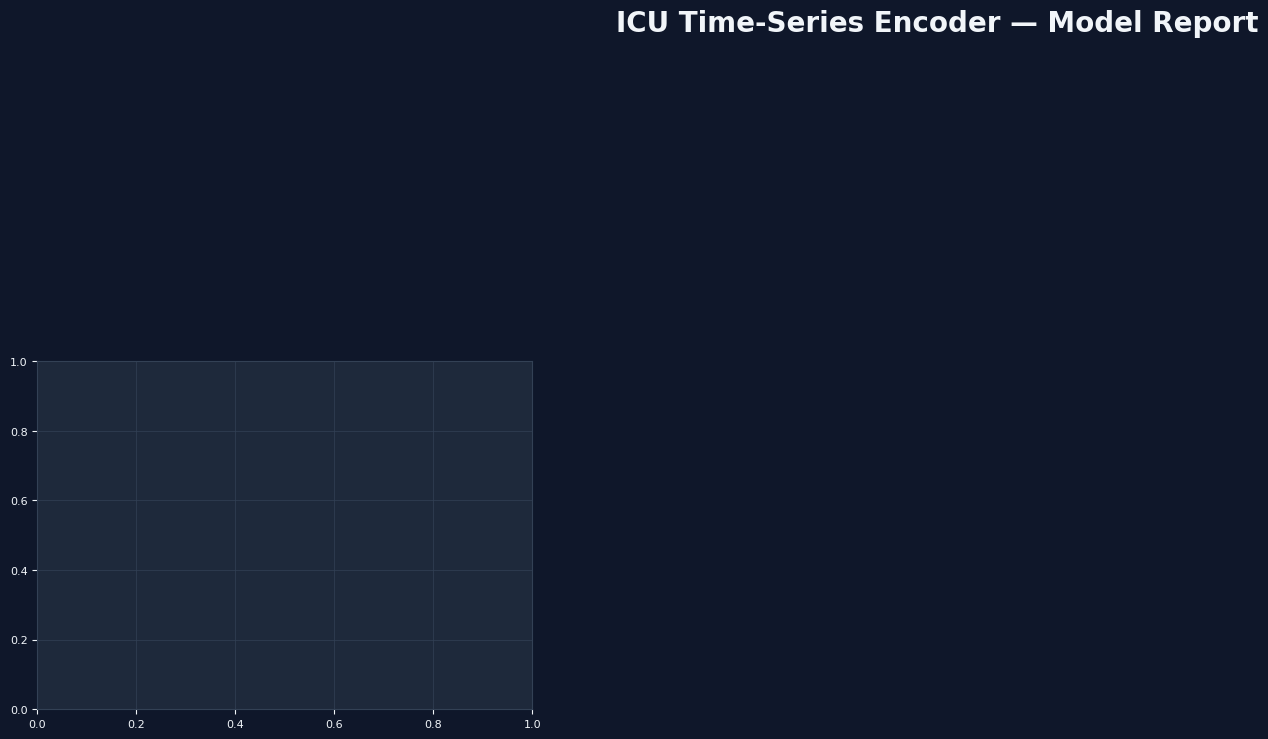

In [76]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.metrics import average_precision_score, confusion_matrix
from sklearn.calibration import calibration_curve
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(24, 32), facecolor=DARK_BG)
fig.suptitle('ICU Time-Series Encoder — Model Report',
             fontsize=20, fontweight='bold', color=TEXT, y=0.99)
gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.52, wspace=0.38)

def sp(ax): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── 1. ROC curves (all 4 tasks)
ax1 = fig.add_subplot(gs[0, 0])
roc_tasks = [
    ('sepsis',   PAL['red'],    'binary'),
    ('organ',    PAL['blue'],   'binary'),
    ('mortality',PAL['teal'],   'binary'),
]
for tname, color, _ in roc_tasks:
    if tname == 'mortality':
        y_prob = trained_models['mortality'].predict(X_test_df.values).clip(0, 1)
        thresh  = np.percentile(y_prob, 70)
        y_true  = (y_test['mortality'] >= thresh).astype(int)
    else:
        y_prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
        y_true = y_test[tname]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{tname} (AUC={auc:.3f})')

# Criticality multiclass ROC (macro OvR)
crit_probs = trained_models['criticality'].predict_proba(X_test_df.values)
# Ensure shape is (n, 5)
n_classes = 5
if crit_probs.shape[1] == n_classes:
    from sklearn.preprocessing import label_binarize
    y_crit_bin = label_binarize(y_test['criticality'], classes=list(range(n_classes)))
    for i, tier in enumerate(['LOW','MOD','HIGH','SEV','CRIT']):
        fpr_i, tpr_i, _ = roc_curve(y_crit_bin[:, i], crit_probs[:, i])
        auc_i = roc_auc_score(y_crit_bin[:, i], crit_probs[:, i])
        ax1.plot(fpr_i, tpr_i, lw=1, linestyle='--',
                 label=f'crit-{tier} (AUC={auc_i:.3f})')

ax1.plot([0,1],[0,1],'--', color=GRID, lw=1)
ax1.set_title('ROC Curve (All Tasks)')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(framealpha=0.2, facecolor=CARD_BG, fontsize=6); sp(ax1)

# ── 2. Precision-Recall curves (sepsis + organ + mortality)
ax2 = fig.add_subplot(gs[0, 1])
for tname, color in [('sepsis', PAL['red']), ('organ', PAL['blue'])]:
    y_prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test[tname], y_prob)
    ap = average_precision_score(y_test[tname], y_prob)
    ax2.plot(rec, prec, color=color, lw=2, label=f'{tname} (AP={ap:.3f})')

# Mortality PR
y_mort_prob = trained_models['mortality'].predict(X_test_df.values).clip(0, 1)
thresh       = np.percentile(y_mort_prob, 70)
y_mort_bin   = (y_test['mortality'] >= thresh).astype(int)
prec, rec, _ = precision_recall_curve(y_mort_bin, y_mort_prob)
ap = average_precision_score(y_mort_bin, y_mort_prob)
ax2.plot(rec, prec, color=PAL['teal'], lw=2, label=f'mortality (AP={ap:.3f})')

ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(framealpha=0.2, facecolor=CARD_BG, fontsize=7); sp(ax2)

# ── 3. Mortality calibration curve
ax3 = fig.add_subplot(gs[0, 2])
y_mort_pred = trained_models['mortality'].predict(X_test_df.values).clip(0, 1)
y_mort_true = y_test['mortality']
thresh  = np.percentile(y_mort_pred, 70)
y_bin   = (y_mort_true >= thresh).astype(int)
frac_pos, mean_pred = calibration_curve(y_bin, y_mort_pred, n_bins=10, strategy='quantile')
ax3.plot(mean_pred, frac_pos, 's-', color=PAL['teal'], lw=2, label='Model')
ax3.plot([0,1],[0,1],'--', color=GRID, lw=1, label='Perfect calibration')
ax3.set_title('Mortality Calibration')
ax3.set_xlabel('Mean predicted'); ax3.set_ylabel('Fraction positive')
ax3.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax3)

# ── 4. SHAP summary — top 20 features for sepsis
ax4 = fig.add_subplot(gs[1, :])
shap_sepsis    = shap_outputs['sepsis'].values
mean_abs_shap  = np.abs(shap_sepsis).mean(axis=0)
top20_idx      = np.argsort(mean_abs_shap)[::-1][:20]

# Guard: FEATURE_COLS must match shap columns length
shap_feat_names = [c.replace('shap_sepsis_', '') for c in shap_df.columns if 'shap_sepsis_' in c]
top20_names = [shap_feat_names[i] for i in top20_idx]
top20_vals  = mean_abs_shap[top20_idx]
colors_shap = [PAL['red'] if v > np.median(top20_vals) else PAL['teal'] for v in top20_vals]
ax4.barh(range(20), top20_vals[::-1], color=colors_shap[::-1], edgecolor=DARK_BG, height=0.7)
ax4.set_yticks(range(20))
ax4.set_yticklabels(top20_names[::-1], fontsize=8)
ax4.set_title('Top 20 Features by SHAP Importance — Sepsis Alert Model')
ax4.set_xlabel('Mean |SHAP value|'); sp(ax4)

# ── 5. Predicted mortality distribution by criticality tier
ax5 = fig.add_subplot(gs[2, :2])
TIER_COLORS = {'LOW':'#16A34A','MODERATE':'#CA8A04','HIGH':'#EA580C',
               'SEVERE':'#DC2626','CRITICAL':'#7C3AED'}
TIER_ORDER  = ['LOW','MODERATE','HIGH','SEVERE','CRITICAL']
test_df_plot = master.loc[test_mask].copy().reset_index(drop=True)
test_df_plot['pred_mortality'] = y_mort_pred
for tier in TIER_ORDER:
    vals = test_df_plot.loc[test_df_plot['criticality_tier'] == tier, 'pred_mortality'] * 100
    if len(vals) < 3: continue
    ax5.hist(vals, bins=40, alpha=0.75, color=TIER_COLORS[tier],
             label=f'{tier} (n={len(vals):,})', edgecolor='none')
ax5.set_title('Predicted Mortality by Criticality Tier (Test Set)')
ax5.set_xlabel('Predicted mortality risk (%)'); ax5.set_ylabel('Stays')
ax5.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax5)

# ── 6. Criticality confusion matrix
ax6 = fig.add_subplot(gs[2, 2])
y_crit_pred = trained_models['criticality'].predict(X_test_df.values).astype(int)
y_crit_true = y_test['criticality'].values.astype(int)
cm = confusion_matrix(y_crit_true, y_crit_pred, normalize='true')
# Pad if not 5x5
if cm.shape[0] < 5:
    pad = np.zeros((5, 5))
    pad[:cm.shape[0], :cm.shape[1]] = cm
    cm = pad
im = ax6.imshow(cm, cmap='Blues', vmin=0, vmax=1)
ax6.set_xticks(range(5)); ax6.set_yticks(range(5))
ax6.set_xticklabels(['L','M','H','S','C'], fontsize=8)
ax6.set_yticklabels(['L','M','H','S','C'], fontsize=8)
for i in range(5):
    for j in range(5):
        ax6.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                 fontsize=7, color='white' if cm[i,j] > 0.5 else TEXT)
ax6.set_title('Criticality Tier\nConfusion Matrix (norm.)')
ax6.set_xlabel('Predicted'); ax6.set_ylabel('True')

# ── 7. AUROC summary bar chart (all 4 tasks)
ax_auc = fig.add_subplot(gs[3, :])
auc_labels, auc_values, auc_colors = [], [], []

for tname, color in [('sepsis', PAL['red']), ('organ', PAL['blue'])]:
    prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
    auc  = roc_auc_score(y_test[tname], prob)
    auc_labels.append(tname); auc_values.append(auc); auc_colors.append(color)

# Mortality
prob  = trained_models['mortality'].predict(X_test_df.values).clip(0, 1)
thresh = np.percentile(prob, 70)
y_bin  = (y_test['mortality'] >= thresh).astype(int)
auc    = roc_auc_score(y_bin, prob)
auc_labels.append('mortality'); auc_values.append(auc); auc_colors.append(PAL['teal'])

# Criticality macro OvR
crit_probs = trained_models['criticality'].predict_proba(X_test_df.values)
from sklearn.preprocessing import label_binarize
y_crit_bin = label_binarize(y_test['criticality'], classes=list(range(5)))
auc_macro  = roc_auc_score(y_crit_bin, crit_probs, multi_class='ovr', average='macro')
auc_labels.append('criticality\n(macro OvR)'); auc_values.append(auc_macro)
auc_colors.append(PAL['purple'])

bars = ax_auc.barh(auc_labels, auc_values, color=auc_colors, edgecolor=DARK_BG, height=0.5)
ax_auc.set_xlim(0, 1.05)
ax_auc.axvline(0.5, color=GRID, lw=1, linestyle='--', label='Random')
ax_auc.axvline(0.8, color=PAL['yellow'], lw=1, linestyle=':', label='Good (0.80)')
for bar, val in zip(bars, auc_values):
    ax_auc.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, color=TEXT)
ax_auc.set_title('AUROC Summary — All Tasks')
ax_auc.set_xlabel('AUROC')
ax_auc.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax_auc)

# ── 8. Feature importance: mortality model SHAP by group
ax7 = fig.add_subplot(gs[4, :])
shap_mort_cols = [c for c in shap_df.columns if 'shap_mortality_' in c]
shap_mort      = shap_outputs['mortality'].values
mean_abs_mort  = np.abs(shap_mort).mean(axis=0)
mort_feat_names = [c.replace('shap_mortality_', '') for c in shap_mort_cols]
feat_df = pd.DataFrame({'feature': mort_feat_names, 'importance': mean_abs_mort})
feat_df['group'] = feat_df['feature'].apply(
    lambda x: 'Static'       if x.startswith('static_') else
              'Missing rate' if x.endswith('_missing_rate') else
              'Vent'         if 'vent' in x else 'Clinical TS'
)
feat_df = feat_df.sort_values('importance', ascending=False).head(25)
group_colors = {'Static': PAL['purple'], 'Missing rate': PAL['yellow'],
                'Vent':   PAL['orange'], 'Clinical TS': PAL['teal']}
bar_colors = [group_colors[g] for g in feat_df['group']]
ax7.barh(range(len(feat_df)), feat_df['importance'].values,
         color=bar_colors, edgecolor=DARK_BG, height=0.7)
ax7.set_yticks(range(len(feat_df)))
ax7.set_yticklabels(feat_df['feature'].values, fontsize=7)
ax7.set_title('Top 25 Feature Importances — Mortality Model (coloured by feature group)')
ax7.set_xlabel('Mean |SHAP value|')
legend_patches = [mpatches.Patch(color=c, label=g) for g, c in group_colors.items()]
ax7.legend(handles=legend_patches, framealpha=0.2, facecolor=CARD_BG, ncol=4)
sp(ax7)

plt.savefig(REPORT_PNG, dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
log.info('Report saved: %s', REPORT_PNG)

## Step 14 — Plain-Language SHAP Explanation Generator
> Given a single stay_id, generate a doctor-readable explanation of why the model predicted what it did.


In [51]:
import pickle
import numpy as np # Ensure numpy is imported

FEATURE_PLAIN_NAMES = {
    'HR_mean':          'average heart rate',
    'HR_max':           'peak heart rate',
    'RR_mean':          'average respiratory rate',
    'SpO2_min':         'lowest blood oxygen level',
    'MAP_min':          'lowest mean arterial pressure',
    'GCS_min':          'lowest consciousness score',
    'Creatinine_max':   'peak creatinine (kidney stress)',
    'Bilirubin_max':    'peak bilirubin (liver stress)',
    'Platelets_min':    'lowest platelet count (clotting)',
    'PF_ratio_min':     'lowest P/F ratio (lung function)',
    'pH_min':           'lowest blood pH (acid-base)',
    'WBC_max':          'peak white cell count (infection)',
    'vent_any':         'mechanical ventilation used',
    'vent_hours':       'hours on ventilator',
    'static_age':       'patient age',
    'static_has_chronic':'chronic disease burden',
    'static_urine_24h': '24h urine output',
    'static_is_elective':'elective admission type',
    'SpO2_missing_rate':'how often SpO2 was not recorded',
    'GCS_missing_rate': 'how often consciousness was not recorded',
}

# Re-define TASK_CONFIG for the explain_stay function to access
TASK_CONFIG = {
    'mortality':   ('regression',  None,  None), # y_train and y_val not needed here
    'sepsis':      ('binary',      None,  None),
    'organ':       ('binary',      None,  None),
    'criticality': ('multiclass',  None,  None),
}

# Redefine TIER_ORDER for multiclass prediction interpretation if not global
TIER_ORDER = ['LOW','MODERATE','HIGH','SEVERE','CRITICAL']

def explain_stay(stay_id: int, task: str = 'sepsis', top_n: int = 5) -> str:
    """
    Generate a plain-language SHAP explanation for one ICU stay.
    task: 'mortality' | 'sepsis' | 'organ' | 'criticality'
    """
    # Get the stay row
    row_idx = master.index[master['stay_id'] == stay_id]
    if len(row_idx) == 0:
        return f'Stay {stay_id} not found.'
    idx = row_idx[0]

    # Load imputer and scaler if not already in scope
    global imputer, scaler
    if 'imputer' not in globals():
        with open(MODEL_DIR / 'imputer.pkl', 'rb') as f: imputer = pickle.load(f)
    if 'scaler' not in globals():
        with open(MODEL_DIR / 'scaler.pkl', 'rb') as f: scaler = pickle.load(f)

    # Get prediction
    x_row = imputer.transform(master.loc[[idx], FEATURE_COLS])
    x_row = scaler.transform(x_row)
    x_df  = pd.DataFrame(x_row, columns=FEATURE_COLS)

    model = trained_models[task]
    task_type = TASK_CONFIG[task][0]

    if task_type == 'regression':
        pred_val = model.predict(x_df.values)[0]
        pred_str = f'{pred_val*100:.1f}% predicted mortality risk'
    elif task_type == 'binary':
        pred_val = model.predict_proba(x_df.values)[:,1][0]
        pred_str = f'{pred_val*100:.1f}% probability ({"HIGH" if pred_val>=0.5 else "LOW"} risk)'
    else: # multiclass
        probs = model.predict_proba(x_df.values)[0]
        tier = TIER_ORDER[np.argmax(probs)]
        pred_str = f'Criticality tier: {tier} (confidence {max(probs)*100:.1f}%)'

    # SHAP for this row
    # Pass the underlying booster object to TreeExplainer
    explainer = shap.TreeExplainer(model.booster)
    sv = explainer.shap_values(x_df)

    # For multiclass, use the CRITICAL class (index 4) if it's available and relevant
    if task_type == 'multiclass':
        # Check if shap_values returns a list of arrays (one per class) or a single array for all classes
        if isinstance(sv, list):
            # Assuming the multiclass model's SHAP values are indexed like the original one (criticality is 4th class)
            sv_use = sv[4] if len(sv) > 4 else sv[np.argmax(probs)] # Use actual predicted class or CRITICAL if available
        else: # Older SHAP versions might return a single array with class dimension
            sv_use = sv[:, 4] if sv.shape[1] > 4 else sv[:, np.argmax(probs)] # Use actual predicted class or CRITICAL if available
    elif isinstance(sv, list):
        sv_use = sv[1] # positive class for binary
    else:
        sv_use = sv # regression or single output
    sv = sv_use.flatten() # Ensure it's a 1D array

    # Top contributors
    top_pos_idx = np.argsort(sv)[::-1][:top_n]
    top_neg_idx = np.argsort(sv)[:top_n]

    lines = [
        f'=== Explanation for Stay {stay_id} — {task.upper()} ===',
        f'Prediction: {pred_str}',
        '',
        'Factors INCREASING this risk:',
    ]
    for i in top_pos_idx:
        if sv[i] <= 0: break
        fname = FEATURE_COLS[i]
        plain = FEATURE_PLAIN_NAMES.get(fname, fname.replace('_',' '))
        raw_val = master.loc[idx, fname]
        lines.append(f'  + {plain}: {raw_val:.2f}  (impact: +{sv[i]:.4f})')

    lines.append('')
    lines.append('Factors DECREASING this risk:')
    for i in top_neg_idx:
        if sv[i] >= 0: break
        fname = FEATURE_COLS[i]
        plain = FEATURE_PLAIN_NAMES.get(fname, fname.replace('_',' '))
        raw_val = master.loc[idx, fname]
        lines.append(f'  - {plain}: {raw_val:.2f}  (impact: {sv[i]:.4f})')

    return '\n'.join(lines)

# Demo: explain first test set stay
demo_stay = master.loc[test_mask, 'stay_id'].iloc[0]
print(explain_stay(demo_stay, task='sepsis'))
print()
print(explain_stay(demo_stay, task='mortality'))

=== Explanation for Stay 30000831 — SEPSIS ===
Prediction: 100.0% probability (HIGH risk)

Factors INCREASING this risk:
  + RR max: 30.00  (impact: +3.3662)
  + SBP min: 86.00  (impact: +3.1124)
  + how often consciousness was not recorded: 0.72  (impact: +1.7411)
  + average respiratory rate: 26.86  (impact: +0.3720)
  + RR missing rate: 0.00  (impact: +0.3329)

Factors DECREASING this risk:
  - RR last: 26.00  (impact: -0.0663)
  - RR min: 22.00  (impact: -0.0315)
  - SF ratio mean: 336.70  (impact: -0.0305)
  - SpO2 std: 2.06  (impact: -0.0274)
  - lowest mean arterial pressure: 65.00  (impact: -0.0244)

=== Explanation for Stay 30000831 — MORTALITY ===
Prediction: 100.0% predicted mortality risk

Factors INCREASING this risk:
  + peak creatinine (kidney stress): 2.30  (impact: +0.0784)
  + PaO2 min: 58.00  (impact: +0.0720)
  + patient age: 78.00  (impact: +0.0632)
  + peak white cell count (infection): 21.30  (impact: +0.0452)
  + chronic disease burden: 1.00  (impact: +0.0449)



## Step 15 — Output Summary

In [52]:
print('=== ICU ENCODER OUTPUTS ===')
for path in [FEAT_OUT, PRED_OUT, REPORT_PNG,
             BASE/'icu_encoder_shap_test.parquet',
             MODEL_DIR/'xgb_mortality.ubj',
             MODEL_DIR/'xgb_sepsis.ubj',
             MODEL_DIR/'xgb_organ.ubj',
             MODEL_DIR/'xgb_criticality.ubj',
             MODEL_DIR/'feature_meta.json',
             MODEL_DIR/'best_hyperparams.json',
             MODEL_DIR/'eval_results.json',
             MODEL_DIR/'imputer.pkl',
             MODEL_DIR/'scaler.pkl']:
    exists = Path(path).exists()
    size   = Path(path).stat().st_size/1e6 if exists else 0
    print(f'  {"OK" if exists else "MISSING":6s} | {size:6.1f} MB | {Path(path).name}')

print(f'\nFeature matrix columns : {len(FEATURE_COLS)}')
print(f'Total stays encoded    : {len(master):,}')
print(f'Train / Val / Test     : {train_mask.sum():,} / {val_mask.sum():,} / {test_mask.sum():,}')
print(f'\nModel performance:')
print(json.dumps(eval_results, indent=2))


=== ICU ENCODER OUTPUTS ===
  OK     |   18.3 MB | icu_encoder_features.parquet
  OK     |    4.2 MB | icu_encoder_predictions.parquet
  OK     |    0.5 MB | icu_encoder_report.png
  MISSING |    0.0 MB | icu_encoder_shap_test.parquet
  OK     |    3.4 MB | xgb_mortality.ubj
  OK     |    0.3 MB | xgb_sepsis.ubj
  OK     |    0.2 MB | xgb_organ.ubj
  OK     |   17.0 MB | xgb_criticality.ubj
  OK     |    0.0 MB | feature_meta.json
  OK     |    0.0 MB | best_hyperparams.json
  OK     |    0.0 MB | eval_results.json
  OK     |    0.0 MB | imputer.pkl
  OK     |    0.0 MB | scaler.pkl

Feature matrix columns : 125
Total stays encoded    : 94,362


NameError: name 'train_mask' is not defined